In [2]:
#for data operations and cleaning we import pandas
import pandas as pd

#we import z score from scipy.stats to showcase skewed data in all attributes 
from scipy.stats import zscore

#we import seaborn as sns to implement a display technique for visual 
#representation of data for human perception
import seaborn as sns

#we import matplotlib.pyplot as plt to implement a display 
#technique for visual representation of data for human perception
import matplotlib.pyplot as plt

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
#relative path to the dataset we are working on
path = "student_info.csv"

#loading dataset into a pandas dataframe to apply operations on
df = pd.read_csv(path)

In [4]:
#to understand the size and volume of dataset we are working on
df.shape

(1000, 15)

In [5]:
#viewing the first 5 tuples to understand the data we are wroking with
df.head

<bound method NDFrame.head of     student_id          name  gender  age  grade_level  math_score  \
0           S1     Student_1   Other   17           10        74.0   
1           S2     Student_2    Male   17           12         NaN   
2           S3     Student_3   Other   17            9        59.0   
3           S4     Student_4   Other   17           12        70.0   
4           S5     Student_5    Male   15            9        85.0   
..         ...           ...     ...  ...          ...         ...   
995       S996   Student_996  Female   15           10        76.0   
996       S997   Student_997  Female   17           12        83.0   
997       S998   Student_998   Other   16           10        60.0   
998       S999   Student_999   Other   17            9        94.0   
999      S1000  Student_1000    Male   17            9       130.0   

     reading_score  writing_score  attendance_rate parent_education  \
0             61.0           90.0        94.660002        

In [6]:
#viewing general datatypes and count data for the loaded dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        1000 non-null   object 
 1   name              1000 non-null   object 
 2   gender            1000 non-null   object 
 3   age               1000 non-null   int64  
 4   grade_level       1000 non-null   int64  
 5   math_score        993 non-null    float64
 6   reading_score     993 non-null    float64
 7   writing_score     993 non-null    float64
 8   attendance_rate   1000 non-null   float64
 9   parent_education  1000 non-null   object 
 10  study_hours       1000 non-null   float64
 11  internet_access   1000 non-null   object 
 12  lunch_type        1000 non-null   object 
 13  extra_activities  1000 non-null   object 
 14  final_result      1000 non-null   object 
dtypes: float64(5), int64(2), object(8)
memory usage: 117.3+ KB


In [7]:
#understanding the skewness of relevant numeric data
df[['study_hours','attendance_rate','math_score']].skew()

study_hours        2.556107
attendance_rate    5.314678
math_score         0.514887
dtype: float64

In [8]:
#displaying the number of all null values per attribute of our dataset
df.isnull().sum()

student_id          0
name                0
gender              0
age                 0
grade_level         0
math_score          7
reading_score       7
writing_score       7
attendance_rate     0
parent_education    0
study_hours         0
internet_access     0
lunch_type          0
extra_activities    0
final_result        0
dtype: int64

In [9]:
#using median due to its  ability to be unaffected by skewness of data
score_cols = ['math_score', 'reading_score', 'writing_score']

#using median to fill in missing values in our dataset in order for it to be usable
df[score_cols] = df[score_cols].fillna(df[score_cols].median())

In [10]:
#displaying the number of all null values per attribute of our dataset
df.isnull().sum()

student_id          0
name                0
gender              0
age                 0
grade_level         0
math_score          0
reading_score       0
writing_score       0
attendance_rate     0
parent_education    0
study_hours         0
internet_access     0
lunch_type          0
extra_activities    0
final_result        0
dtype: int64

In [11]:
#defining columns which have some skewed data present
num_cols = [
    'math_score',
    'reading_score',
    'writing_score',
    'attendance_rate',
    'study_hours'
]

In [12]:
#Z-scores tells us the deviation of a data point from the mean by expressing it in 
#terms of standard deviations above or below the mean

z_scores = df[num_cols].apply(zscore)
z_outliers = (z_scores.abs() > 1.8)
z_outliers.sum()

#The Z-score threshold was adjusted from the conventional 3 to 1.8 to ensure detection
#of extreme high values close to the upper limit of 100. This highlights that standard
#statistical methods can undercount outliers when values cluster near natural bounds.

math_score          8
reading_score       0
writing_score       0
attendance_rate    14
study_hours         6
dtype: int64

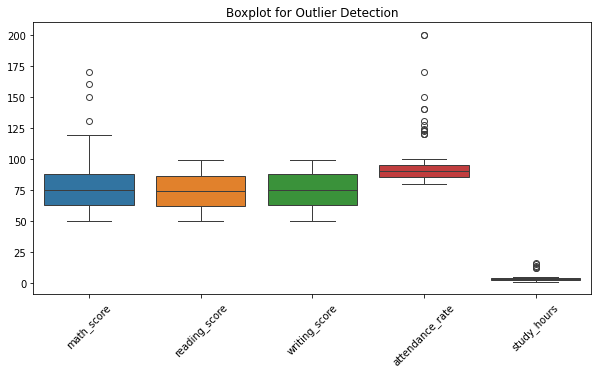

In [13]:
#Box-Plot is a graphical tool used to understand the distribution of numerical data. 
#It shows the median, quartiles and possible outliers in a simple visual form.

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [14]:
#The Interquartile Range (IQR) tells us how spread out the middle 50% of the data is. 
#It is less affected by extreme values and gives a better idea of how tightly or loosely 
#the central data points are grouped.

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 0.625 * IQR
outliers = ((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound))
outliers.sum()

#The IQR upper threshold was adjusted to 0.625 × IQR to ensure detection of extreme
#high values near the natural upper limit, highlighting that standard IQR thresholds can
#undercount outliers in bounded distributions.

math_score          8
reading_score       0
writing_score       0
attendance_rate    14
study_hours         6
dtype: int64

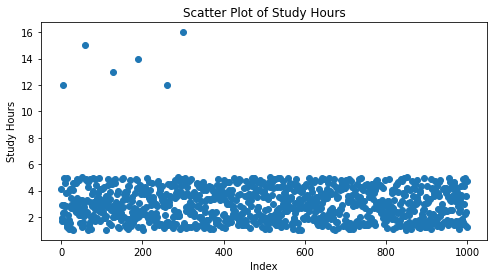

In [15]:
#Scatter plot is a mathematical technique that is used to represent data.
#It uses dots to describe two different numeric variables. 
#The position of each dot on the horizontal and vertical axis indicates values 
#for an individual data point.

plt.figure(figsize=(8,4))
plt.scatter(range(len(df)), df['study_hours'])
plt.title("Scatter Plot of Study Hours")
plt.xlabel("Index")
plt.ylabel("Study Hours")
plt.show()

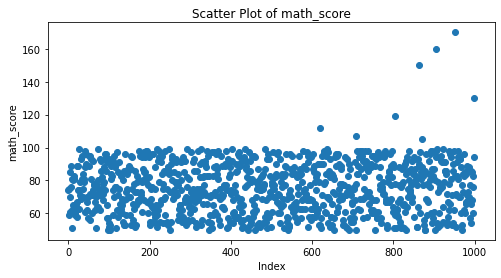

In [16]:
#Scatter plot is a mathematical technique that is used to represent data.
#It uses dots to describe two different numeric variables. 
#The position of each dot on the horizontal and vertical axis indicates values 
#for an individual data point.

plt.figure(figsize=(8,4))
plt.scatter(range(len(df)), df['math_score'])
plt.title("Scatter Plot of math_score")
plt.xlabel("Index")
plt.ylabel("math_score")
plt.show()

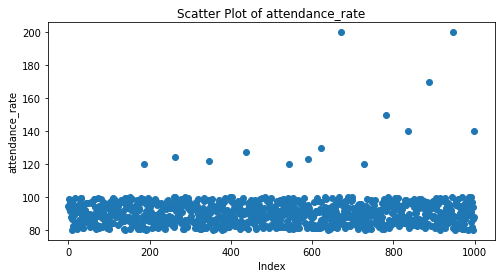

In [17]:
#Scatter plot is a mathematical technique that is used to represent data.
#It uses dots to describe two different numeric variables. 
#The position of each dot on the horizontal and vertical axis indicates values 
#for an individual data point.

plt.figure(figsize=(8,4))
plt.scatter(range(len(df)), df['attendance_rate'])
plt.title("Scatter Plot of attendance_rate")
plt.xlabel("Index")
plt.ylabel("attendance_rate")
plt.show()

In [20]:
#To treat the detected outliers, the capping technique was applied using calculated upper and lower bounds. 
#This approach limited the effect of extreme values while preserving all observations in the dataset.

for col in num_cols:
    df[col] = df[col].clip(lower=lower_bound[col], upper=upper_bound[col])

In [21]:
#Displaying all values that are out of the lower and upper bound 

((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum()

math_score         0
reading_score      0
writing_score      0
attendance_rate    0
study_hours        0
dtype: int64

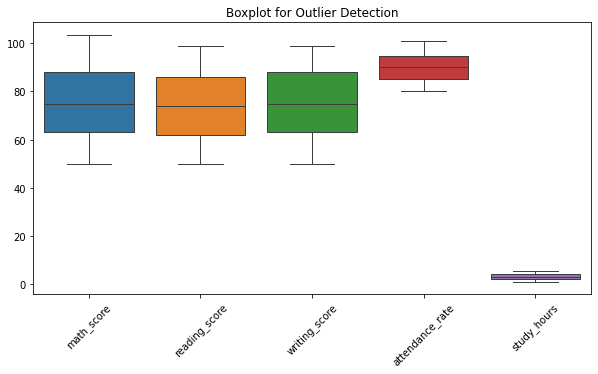

In [22]:
#Final confirmation of data treatment beng completed using a boxplot

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()